# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [5]:
# Crating database connection
conn = sqlite3.connect('inventory.db')

# Loading data from the database
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,PurchasePrice,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,26.27,36.99,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,23.19,28.99,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,18.24,24.99,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,16.17,22.99,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [7]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,10640.705203,18700.404409,2.000000,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,18054.503193,12643.196784,58.000000,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,24.402095,109.483355,0.360000,6.840000,10.450000,19.470000,5.681810e+03
ActualPrice,10648.0,35.671184,148.534066,0.490000,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10648.0,3145.159936,11113.367455,1.000000,36.000000,261.000000,1981.250000,3.376600e+05
TotalPurchaseDollars,10648.0,30138.163064,123277.154715,0.710000,452.857500,3646.725000,20764.170000,3.811252e+06
TotalSalesQuantity,10648.0,3081.902047,10971.073340,0.000000,33.000000,260.500000,1934.250000,3.349390e+05
TotalSalesDollars,10648.0,42302.921643,167947.264974,0.000000,728.275000,5285.915000,28414.050000,5.101920e+06
TotalSalesPrice,10648.0,18813.647626,45018.406384,0.000000,288.830000,2841.775000,16080.270000,6.728193e+05
TotalExciseTax,10648.0,1775.333762,10992.438862,0.000000,4.800000,46.355000,418.375000,3.682428e+05


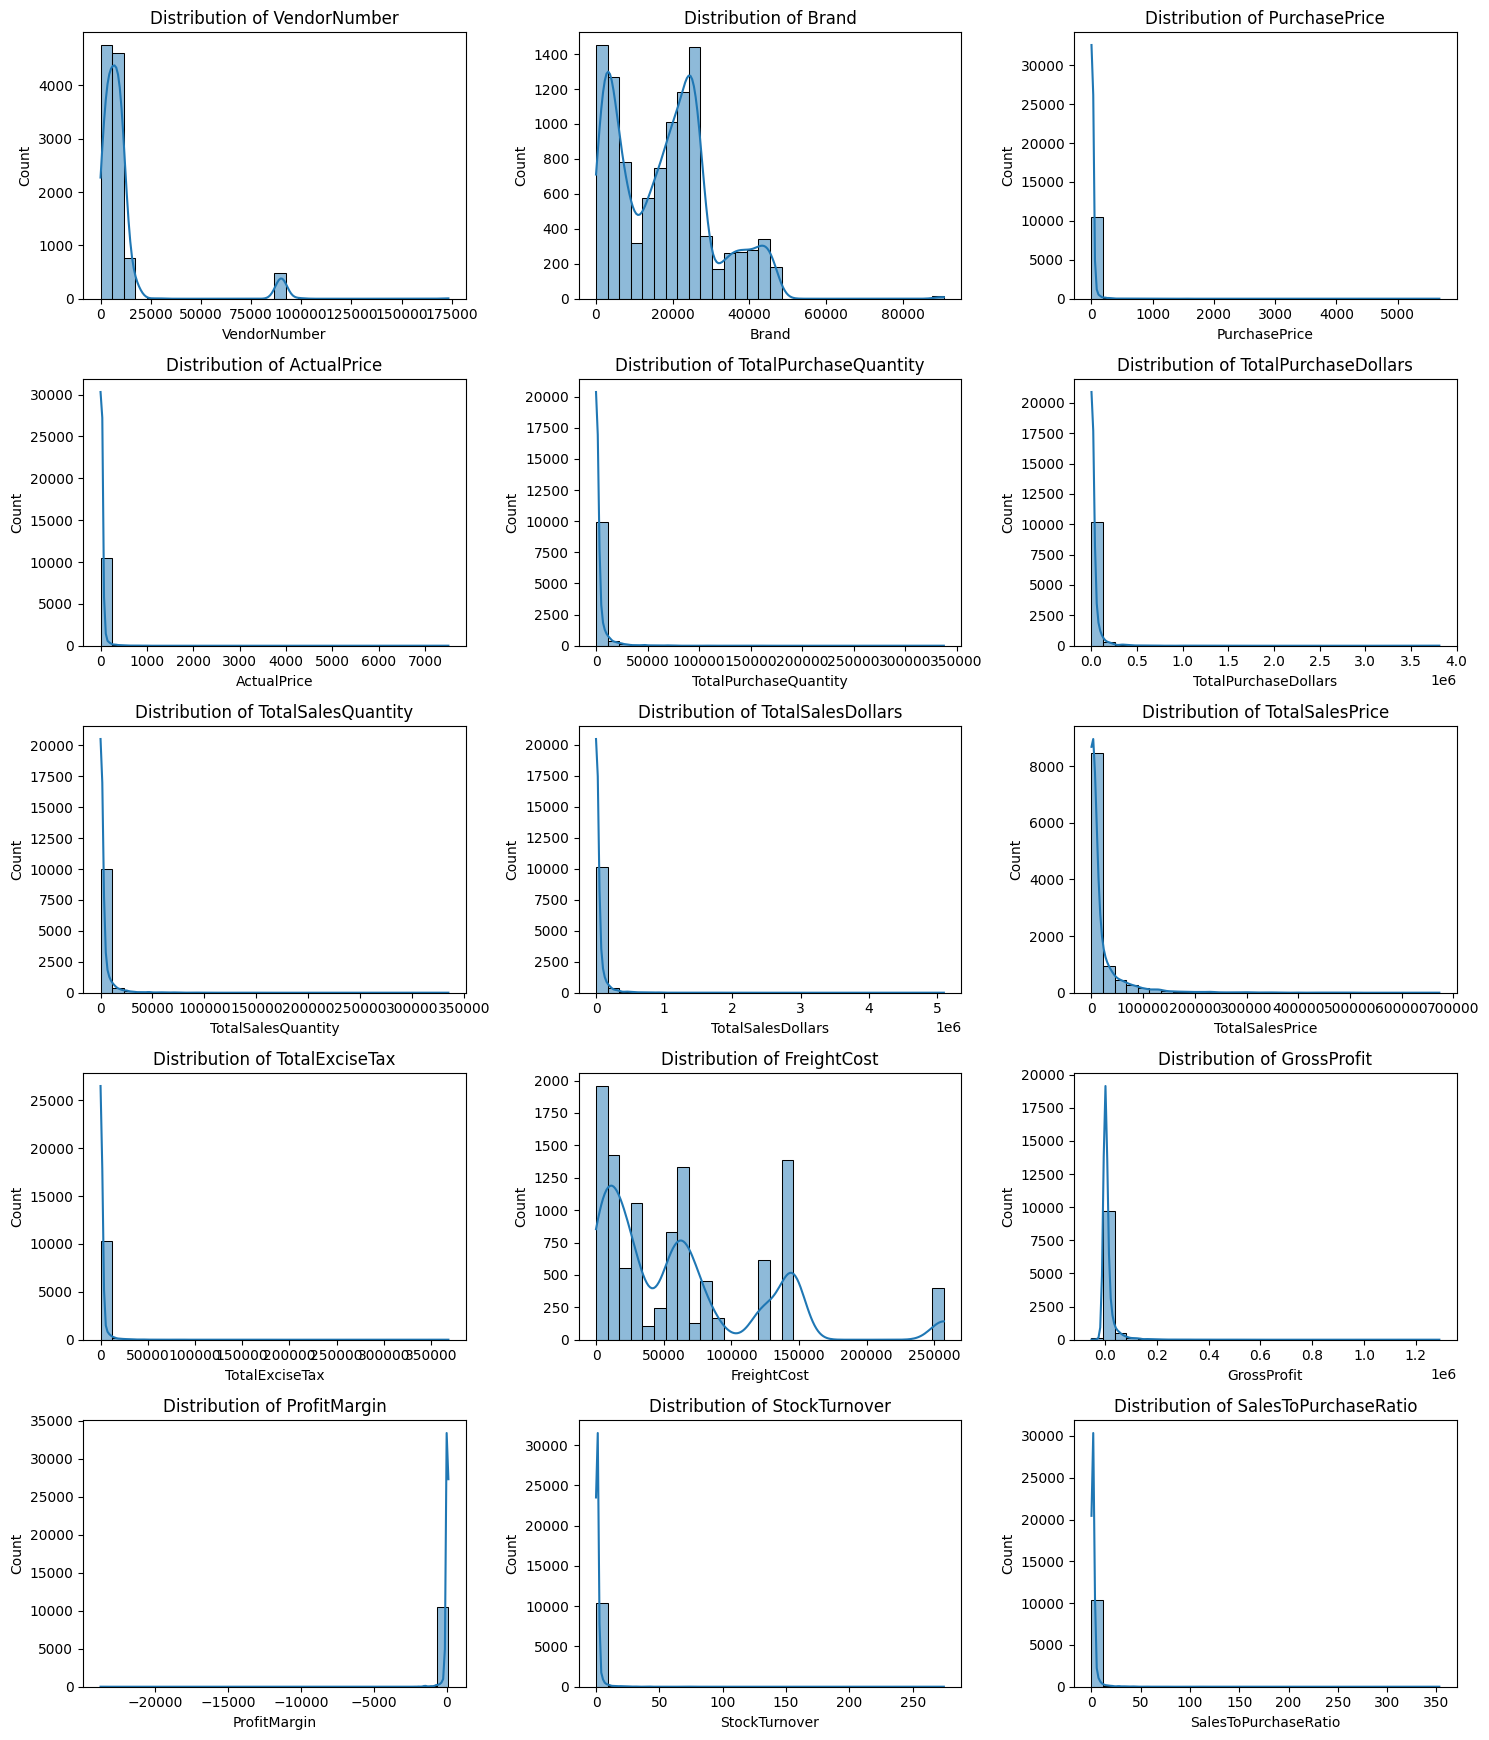

In [ ]:
# Distribution plots for numeric features
numerical_col = df.select_dtypes(include=np.number).columns

n = len(numerical_col)
ncols = 3
nrows = int(np.ceil(n / ncols)) if n > 0 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_col):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(numerical_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

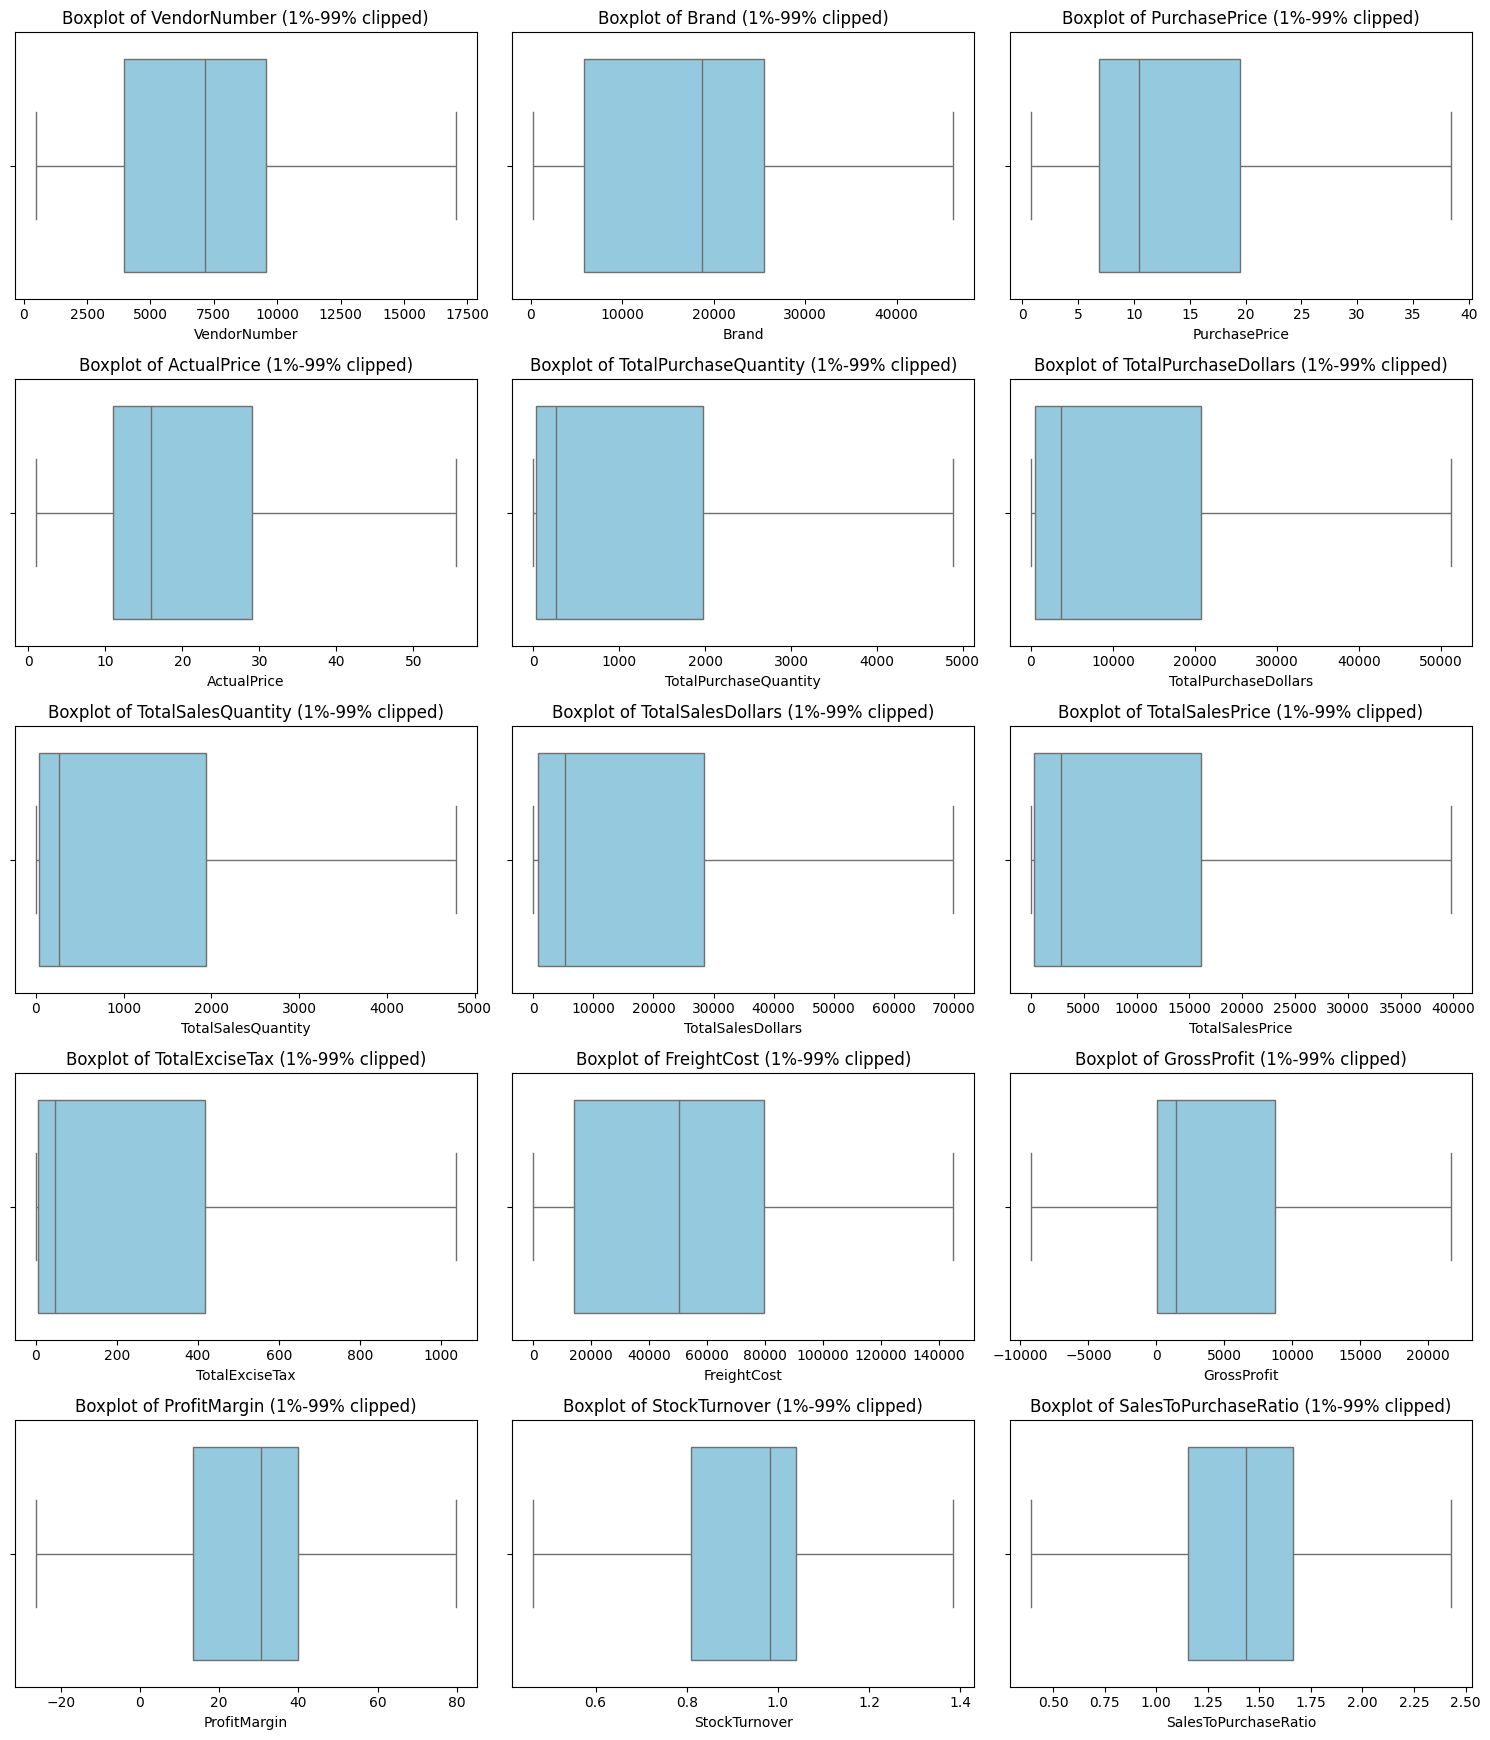

In [14]:
# Boxplots with outlier clipping (1st-99th percentile)
num_cols = df.select_dtypes(include=np.number).columns

n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols)) if n > 0 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    series = df[col].dropna()
    lower = series.quantile(0.01)
    upper = series.quantile(0.99)
    clipped = series.clip(lower=lower, upper=upper)

    sns.boxplot(x=clipped, ax=axes[i], color="skyblue", showfliers=False)
    axes[i].set_title(f"Boxplot of {col} (1%-99% clipped)")
    axes[i].set_xlabel(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Summary Statistics Insights

### Negative & Zero Values

- **Gross Profit:** Minimum value is **-52,002.78**, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

- **Profit Margin:** Has a minimum of **-∞**, which suggests cases where revenue is zero or even lower than costs.

- **Total Sales Quantity & Sales Dollars:** Minimum values are **0**, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

---

### Outliers Indicated by High Standard Deviations

- **Purchase & Actual Prices:** The max values (**5,681.81 & 7,499.99**) are significantly higher than the mean (**24.39 & 35.64**), indicating potential premium products.

- **Freight Cost:** Huge variation, from **0.09 to 257,032.07**, suggests logistics inefficiencies or bulk shipments.

- **Stock Turnover:** Ranges from **0 to 274.5**, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.

In [16]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query(
    """
    select * from vendor_sales_summary
    where GrossProfit > 0 and ProfitMargin > 0 and TotalSalesQuantity > 0
    """,
    conn
)

In [17]:
df

,VendorNumber,VendorName,Brand,PurchasePrice,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,26.27,36.99,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,23.19,28.99,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,18.24,24.99,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,16.17,22.99,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8536,9815,WINE GROUP INC,8527,1.32,4.99,2,2.64,5,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8537,8004,SAZERAC CO INC,5683,0.39,0.49,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8538,3924,HEAVEN HILL DISTILLERIES,9123,0.74,0.99,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8539,3960,DIAGEO NORTH AMERICA INC,6127,1.47,1.99,1,1.47,72,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [21]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'PurchasePrice', 'ActualPrice',
       'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity',
       'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost',
       'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio'],
      dtype='str')

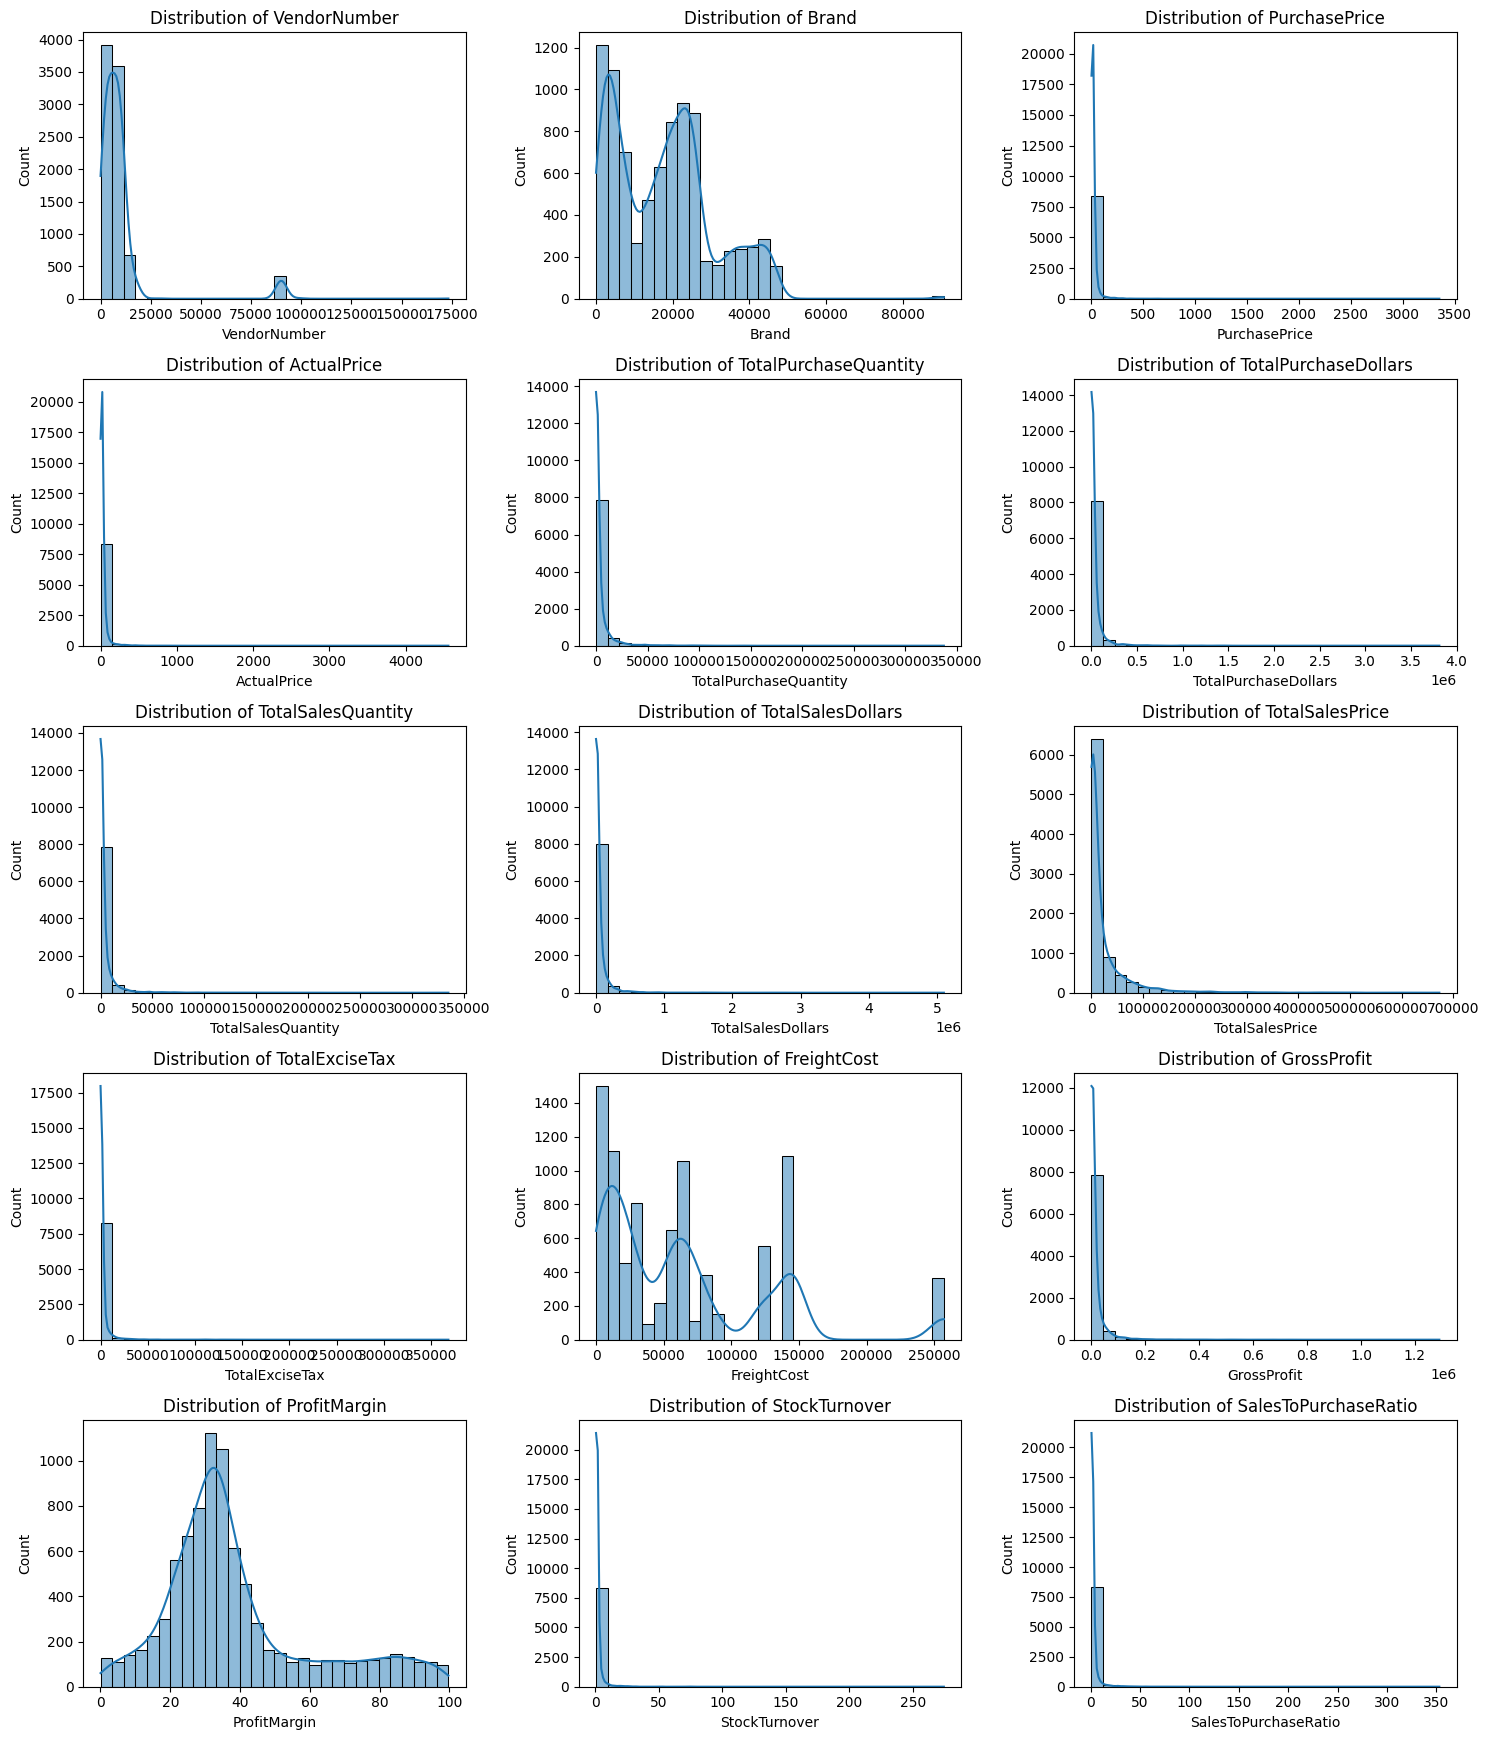

In [20]:
# Distribution plots for numeric features
numerical_col = df.select_dtypes(include=np.number).columns

n = len(numerical_col)
ncols = 3
nrows = int(np.ceil(n / ncols)) if n > 0 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_col):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(numerical_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

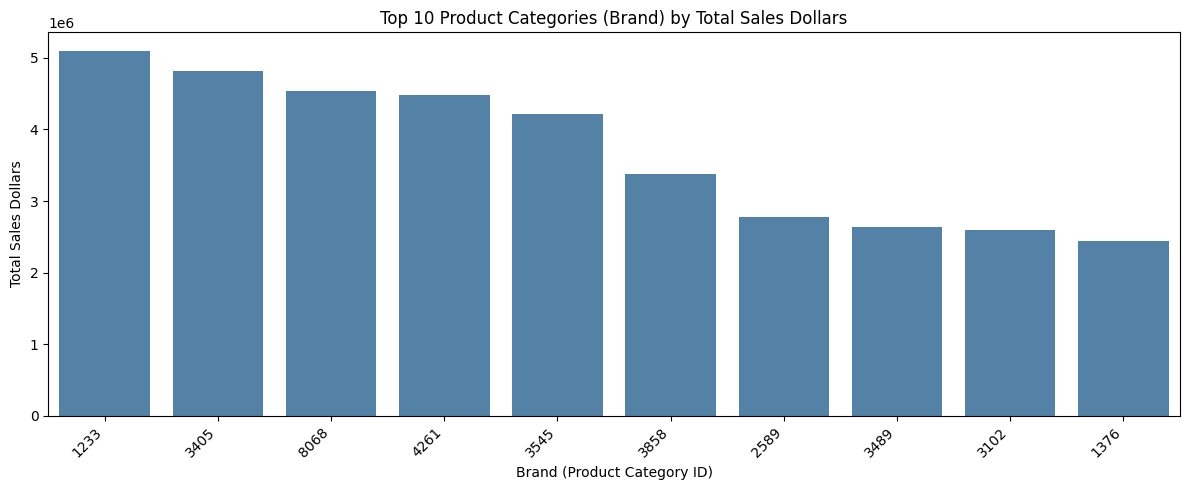

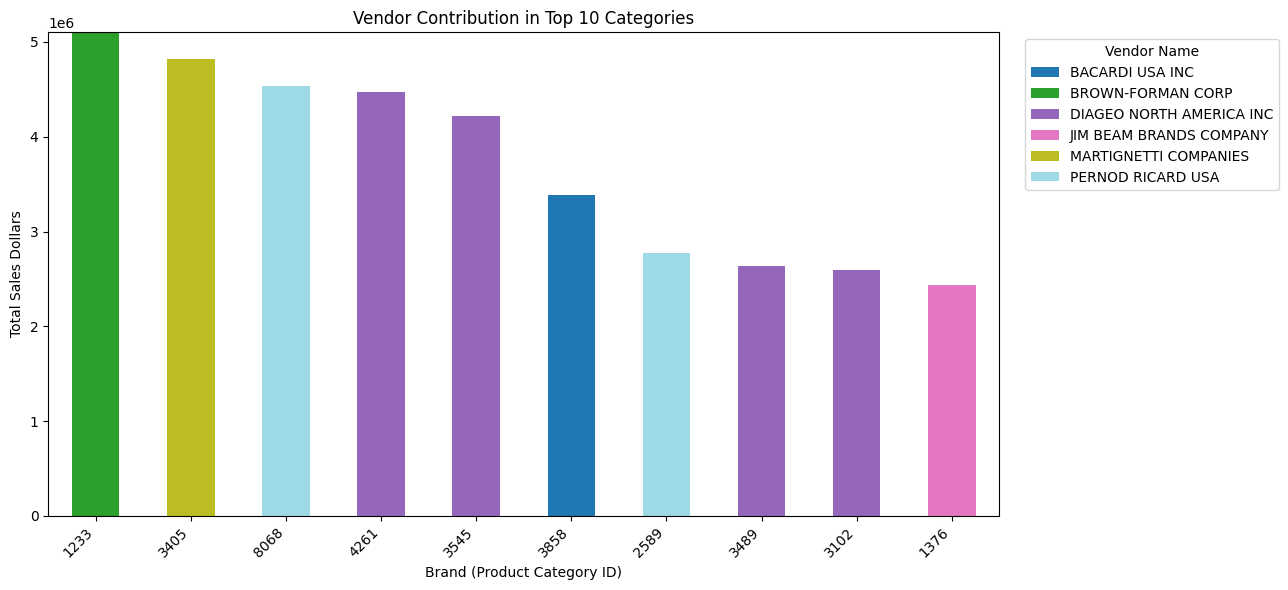

,Brand,TotalSalesDollars
498,1233,5101919.51
1360,3405,4819073.49
2688,8068,4538120.60
1783,4261,4475972.88
1426,3545,4223107.62
1607,3858,3383912.40
941,2589,2773367.73
1398,3489,2640491.19
1221,3102,2592041.35
551,1376,2435393.39


In [23]:
# Top 10 product categories (Brand) and contributing vendors
if "Brand" not in df.columns or "VendorName" not in df.columns:
    raise ValueError("Required columns 'Brand' and/or 'VendorName' are missing from df")

# In this table, Brand is the closest available product/category field.
# If you later add a ProductName column, replace Brand with ProductName below.
top10_brand = (
    df.groupby("Brand", as_index=False)["TotalSalesDollars"]
      .sum()
      .sort_values("TotalSalesDollars", ascending=False)
      .head(10)
      .copy()
)
top10_brand["Brand"] = top10_brand["Brand"].astype(str)

top10_df = df[df["Brand"].isin(top10_brand["Brand"].astype(df["Brand"].dtype))].copy()
top10_df["Brand"] = top10_df["Brand"].astype(str)

# Keep top 3 vendors per category for readable charting
vendor_share = (
    top10_df.groupby(["Brand", "VendorName"], as_index=False)["TotalSalesDollars"]
            .sum()
            .sort_values(["Brand", "TotalSalesDollars"], ascending=[True, False])
            .groupby("Brand", as_index=False)
            .head(3)
)

# Plot 1: Top 10 categories by sales
plt.figure(figsize=(12, 5))
sns.barplot(data=top10_brand, x="Brand", y="TotalSalesDollars", color="steelblue")
plt.title("Top 10 Product Categories (Brand) by Total Sales Dollars")
plt.xlabel("Brand (Product Category ID)")
plt.ylabel("Total Sales Dollars")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot 2: Vendor contribution within each top category
vendor_pivot = vendor_share.pivot(index="Brand", columns="VendorName", values="TotalSalesDollars").fillna(0)
vendor_pivot = vendor_pivot.loc[top10_brand["Brand"]]

ax = vendor_pivot.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="tab20")
ax.set_title("Vendor Contribution in Top 10 Categories")
ax.set_xlabel("Brand (Product Category ID)")
ax.set_ylabel("Total Sales Dollars")
ax.legend(title="Vendor Name", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top10_brand

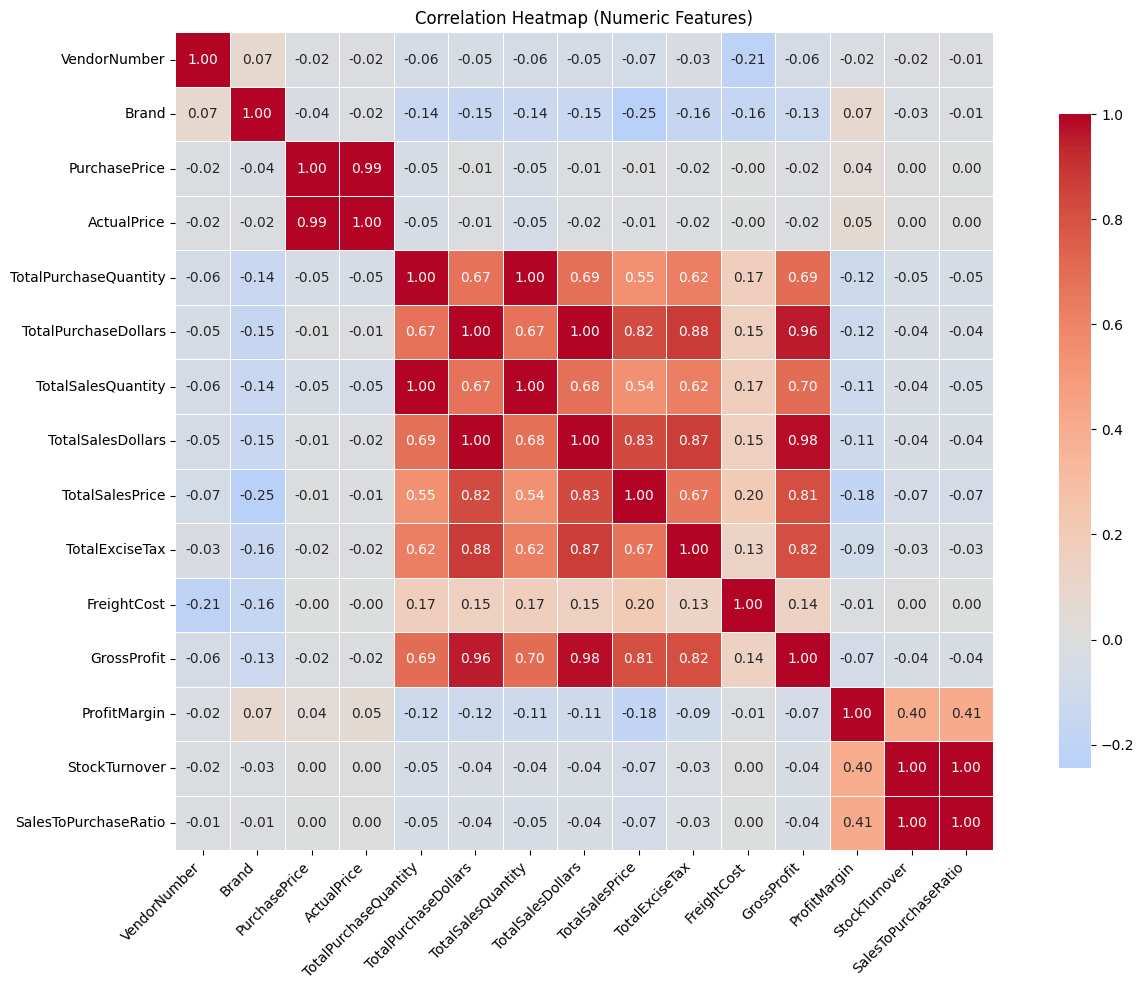

In [25]:
# Correlation heatmap for numeric features
corr_df = df.select_dtypes(include=np.number).copy()

if corr_df.shape[1] < 2:
    raise ValueError("Need at least two numeric columns to compute correlation.")

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
 )
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Correlation Insights

- **PurchasePrice:** Has weak correlations with **TotalSalesDollars (-0.012)** and **GrossProfit (-0.016)**, suggesting that price variations do not significantly impact sales revenue or profit.

- **Purchase Quantity vs Sales Quantity:** Strong correlation (**0.999**), confirming efficient inventory turnover.

- **Profit Margin vs Total Sales Price:** Negative correlation (**-0.179**) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

- **Stock Turnover:** Has weak negative correlations with both **GrossProfit (-0.038)** and **ProfitMargin (-0.055)**, indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis

Identify brands that need promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.

Low Sales threshold (Q1): 1,349.85
High Margin threshold (Q3): 44.07
Top action list size: 25


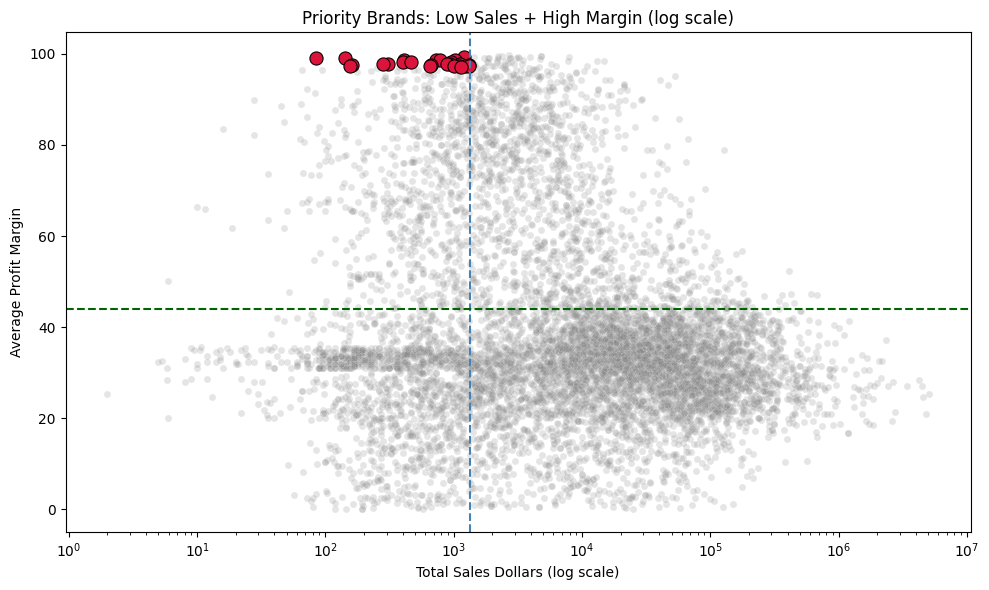

,Brand,VendorName,TotalSalesDollars,ProfitMargin,GrossProfit,TotalSalesQuantity
0,40583,KOBRAND CORPORATION,1208.90,99.393664,1201.57,110
1,3065,PROXIMO SPIRITS INC.,85.14,99.166079,84.43,86
2,6127,DIAGEO NORTH AMERICA INC,143.28,98.974037,141.81,72
3,24559,M S WALKER INC,1019.49,98.683656,1006.07,51
4,8151,M S WALKER INC,410.85,98.617500,405.17,415
5,12253,ULTRA BEVERAGE COMPANY LLP,735.08,98.579746,724.64,92
6,788,JIM BEAM BRANDS COMPANY,779.48,98.564428,768.29,52
7,4424,SAZERAC CO INC,945.14,98.224602,928.36,86
8,4357,BACARDI USA INC,399.60,98.133133,392.14,40
9,8563,SAZERAC NORTH AMERICA INC.,461.58,98.110837,452.86,42


In [30]:
# Efficient brand screening: aggregate in SQL, filter in pandas
brand_perf = pd.read_sql_query(
    """
    SELECT
        Brand,
        VendorName,
        SUM(TotalSalesDollars) AS TotalSalesDollars,
        AVG(ProfitMargin) AS ProfitMargin,
        SUM(GrossProfit) AS GrossProfit,
        SUM(TotalSalesQuantity) AS TotalSalesQuantity
    FROM vendor_sales_summary
    WHERE GrossProfit > 0 AND ProfitMargin > 0 AND TotalSalesQuantity > 0
    GROUP BY Brand, VendorName
    """,
    conn
)

sales_q1 = brand_perf["TotalSalesDollars"].quantile(0.25)
margin_q3 = brand_perf["ProfitMargin"].quantile(0.75)

adjustment_candidates = (
    brand_perf.query("TotalSalesDollars <= @sales_q1 and ProfitMargin >= @margin_q3")
    .sort_values(["ProfitMargin", "TotalSalesDollars"], ascending=[False, True])
    .head(25)
    .reset_index(drop=True)
)

print(f"Low Sales threshold (Q1): {sales_q1:,.2f}")
print(f"High Margin threshold (Q3): {margin_q3:,.2f}")
print(f"Top action list size: {len(adjustment_candidates)}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_perf, x="TotalSalesDollars", y="ProfitMargin",
                alpha=0.2, s=25, color="gray")
sns.scatterplot(data=adjustment_candidates, x="TotalSalesDollars", y="ProfitMargin",
                s=90, color="crimson", edgecolor="black")
plt.xscale("log")
plt.axvline(sales_q1, ls="--", color="steelblue")
plt.axhline(margin_q3, ls="--", color="darkgreen")
plt.title("Priority Brands: Low Sales + High Margin (log scale)")
plt.xlabel("Total Sales Dollars (log scale)")
plt.ylabel("Average Profit Margin")
plt.tight_layout()
plt.show()

adjustment_candidates

**Which vendors and brands demonstrate the heighest sales performane**

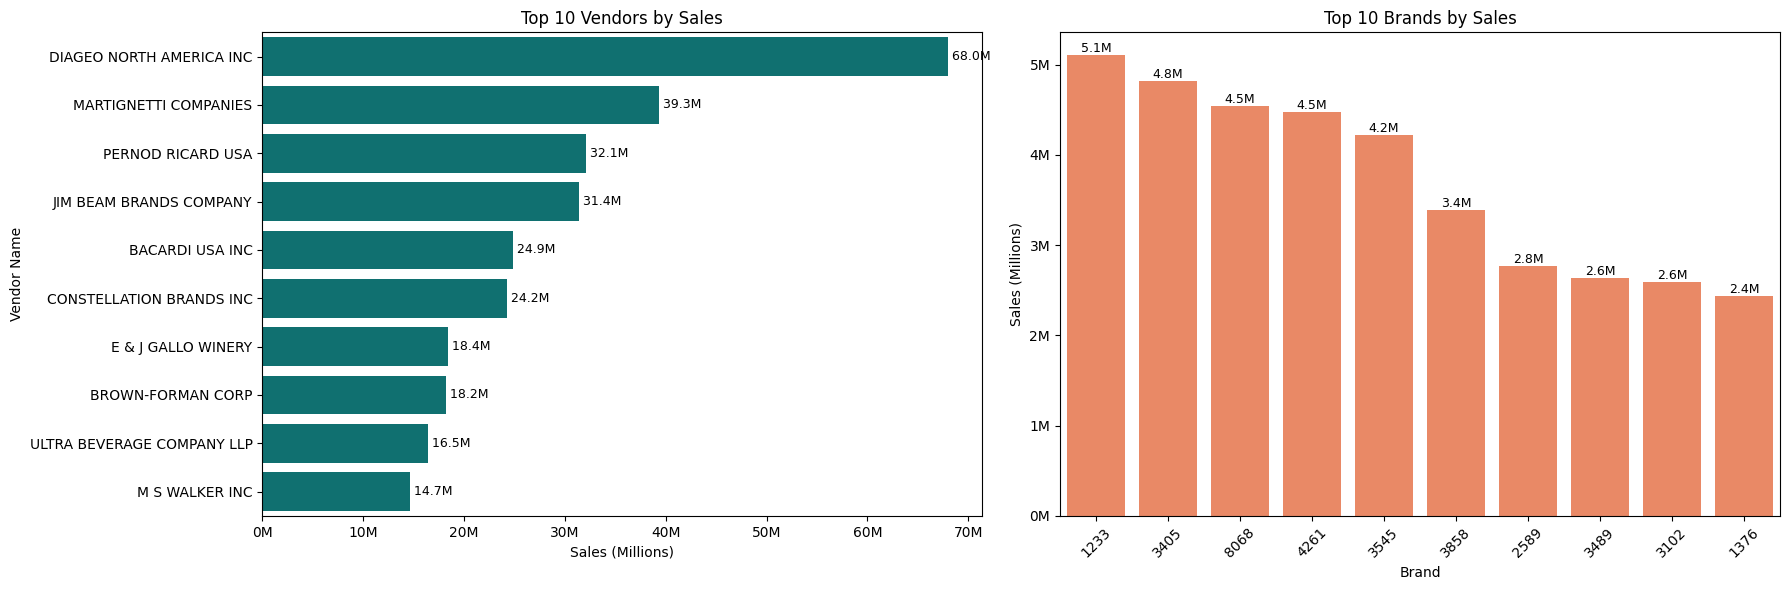

(                     VendorName TotalSalesDollars
 25     DIAGEO NORTH AMERICA INC            67.99M
 56        MARTIGNETTI COMPANIES            39.33M
 67            PERNOD RICARD USA            32.06M
 45      JIM BEAM BRANDS COMPANY            31.42M
 6               BACARDI USA INC            24.85M
 20     CONSTELLATION BRANDS INC            24.22M
 30           E & J GALLO WINERY            18.40M
 11            BROWN-FORMAN CORP            18.25M
 105  ULTRA BEVERAGE COMPANY LLP            16.46M
 52               M S WALKER INC            14.68M,
      Brand TotalSalesDollars
 498   1233             5.10M
 1360  3405             4.82M
 2688  8068             4.54M
 1783  4261             4.48M
 1426  3545             4.22M
 1607  3858             3.38M
 941   2589             2.77M
 1398  3489             2.64M
 1221  3102             2.59M
 551   1376             2.44M)

In [33]:
# Top 10 visualization: Vendor by Sales and Brand by Sales (readable $M format)
from matplotlib.ticker import FuncFormatter

top10_vendor_sales = (
    df.groupby("VendorName", as_index=False)["TotalSalesDollars"]
      .sum()
      .sort_values("TotalSalesDollars", ascending=False)
      .head(10)
)

top10_brand_sales = (
    df.groupby("Brand", as_index=False)["TotalSalesDollars"]
      .sum()
      .sort_values("TotalSalesDollars", ascending=False)
      .head(10)
)
top10_brand_sales["Brand"] = top10_brand_sales["Brand"].astype(str)

def fmt_millions(x, _):
    return f"{x/1_000_000:.0f}M"

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=top10_vendor_sales,
    y="VendorName",
    x="TotalSalesDollars",
    ax=axes[0],
    color="teal"
 )
axes[0].set_title("Top 10 Vendors by Sales")
axes[0].set_xlabel("Sales (Millions)")
axes[0].set_ylabel("Vendor Name")
axes[0].xaxis.set_major_formatter(FuncFormatter(fmt_millions))

for p in axes[0].patches:
    w = p.get_width()
    y = p.get_y() + p.get_height() / 2
    axes[0].text(w, y, f" {w/1_000_000:.1f}M", va="center", ha="left", fontsize=9)

sns.barplot(
    data=top10_brand_sales,
    x="Brand",
    y="TotalSalesDollars",
    ax=axes[1],
    color="coral"
 )
axes[1].set_title("Top 10 Brands by Sales")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Sales (Millions)")
axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_millions))
axes[1].tick_params(axis="x", rotation=45)

for p in axes[1].patches:
    h = p.get_height()
    x = p.get_x() + p.get_width() / 2
    axes[1].text(x, h, f"{h/1_000_000:.1f}M", va="bottom", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

top10_vendor_sales_display = top10_vendor_sales.copy()
top10_vendor_sales_display["TotalSalesDollars"] = (
    top10_vendor_sales_display["TotalSalesDollars"] / 1_000_000
).map(lambda v: f"{v:.2f}M")

top10_brand_sales_display = top10_brand_sales.copy()
top10_brand_sales_display["TotalSalesDollars"] = (
    top10_brand_sales_display["TotalSalesDollars"] / 1_000_000
).map(lambda v: f"{v:.2f}M")

top10_vendor_sales_display, top10_brand_sales_display

In [31]:
# Highest sales-performing vendor-brand pairs (data-engineer style SQL)
top_vendor_brand_query = """
WITH perf AS (
    SELECT
        VendorNumber,
        VendorName,
        Brand,
        SUM(TotalSalesDollars) AS total_sales_dollars,
        SUM(TotalSalesQuantity) AS total_sales_qty,
        SUM(GrossProfit) AS total_gross_profit,
        AVG(ProfitMargin) AS avg_profit_margin
    FROM vendor_sales_summary
    WHERE TotalSalesDollars > 0
    GROUP BY VendorNumber, VendorName, Brand
)
SELECT
    VendorNumber,
    VendorName,
    Brand,
    total_sales_dollars,
    total_sales_qty,
    total_gross_profit,
    ROUND(avg_profit_margin, 2) AS avg_profit_margin,
    DENSE_RANK() OVER (ORDER BY total_sales_dollars DESC) AS sales_rank
FROM perf
ORDER BY total_sales_dollars DESC
LIMIT 20;
"""

top_vendor_brand = pd.read_sql_query(top_vendor_brand_query, conn)
top_vendor_brand

,VendorNumber,VendorName,Brand,total_sales_dollars,total_sales_qty,total_gross_profit,avg_profit_margin,sales_rank
0,1128,BROWN-FORMAN CORP,1233,5101919.51,142049,1290667.91,25.30,1
1,4425,MARTIGNETTI COMPANIES,3405,4819073.49,160247,1015032.27,21.06,2
2,17035,PERNOD RICARD USA,8068,4538120.60,187140,1119816.92,24.68,3
3,3960,DIAGEO NORTH AMERICA INC,4261,4475972.88,200412,1214774.94,27.14,4
4,3960,DIAGEO NORTH AMERICA INC,3545,4223107.62,135838,1199901.61,28.41,5
5,480,BACARDI USA INC,3858,3383912.40,141860,917276.47,27.11,6
6,17035,PERNOD RICARD USA,2589,2773367.73,69627,596082.65,21.49,7
7,3960,DIAGEO NORTH AMERICA INC,3489,2640491.19,90481,736751.64,27.90,8
8,3960,DIAGEO NORTH AMERICA INC,3102,2592041.35,148265,503706.51,19.43,9
9,12546,JIM BEAM BRANDS COMPANY,1376,2435393.39,107061,661966.25,27.18,10


**Which vendors contribute the most to total purchases dolars?**

In [34]:
# Vendors contributing most to total purchase dollars
top_vendor_purchase_query = """
SELECT
    VendorNumber,
    VendorName,
    SUM(TotalPurchaseDollars) AS total_purchase_dollars,
    DENSE_RANK() OVER (ORDER BY SUM(TotalPurchaseDollars) DESC) AS purchase_rank
FROM vendor_sales_summary
GROUP BY VendorNumber, VendorName
ORDER BY total_purchase_dollars DESC
LIMIT 10;
"""

top_vendor_purchase = pd.read_sql_query(top_vendor_purchase_query, conn)
top_vendor_purchase_display = top_vendor_purchase.copy()
top_vendor_purchase_display["total_purchase_dollars"] = (
    top_vendor_purchase_display["total_purchase_dollars"] / 1_000_000
).map(lambda v: f"{v:.2f}M")

top_vendor_purchase_display

,VendorNumber,VendorName,total_purchase_dollars,purchase_rank
0,3960,DIAGEO NORTH AMERICA INC,50.96M,1
1,4425,MARTIGNETTI COMPANIES,27.85M,2
2,12546,JIM BEAM BRANDS COMPANY,24.20M,3
3,17035,PERNOD RICARD USA,24.12M,4
4,480,BACARDI USA INC,17.62M,5
5,1392,CONSTELLATION BRANDS INC,15.57M,6
6,1128,BROWN-FORMAN CORP,13.53M,7
7,9165,ULTRA BEVERAGE COMPANY LLP,13.10M,8
8,3252,E & J GALLO WINERY,12.29M,9
9,9552,M S WALKER INC,10.92M,10


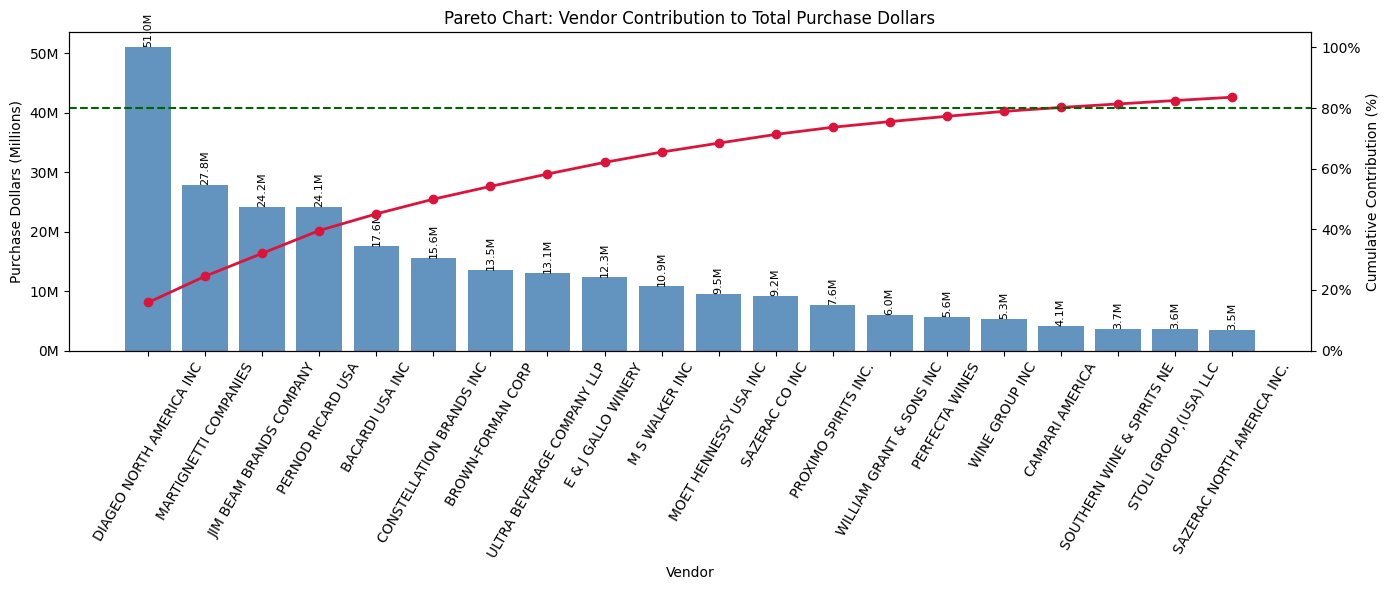

Vendors needed to reach ~80% of purchase dollars: 17


,Rank,VendorName,Purchase Dollars,Share of Total,Cumulative Share
0,1,DIAGEO NORTH AMERICA INC,50.96M,15.88%,15.88%
1,2,MARTIGNETTI COMPANIES,27.85M,8.68%,24.56%
2,3,JIM BEAM BRANDS COMPANY,24.20M,7.54%,32.10%
3,4,PERNOD RICARD USA,24.12M,7.52%,39.62%
4,5,BACARDI USA INC,17.62M,5.49%,45.11%
5,6,CONSTELLATION BRANDS INC,15.57M,4.85%,49.96%
6,7,BROWN-FORMAN CORP,13.53M,4.22%,54.18%
7,8,ULTRA BEVERAGE COMPANY LLP,13.10M,4.08%,58.26%
8,9,E & J GALLO WINERY,12.29M,3.83%,62.09%
9,10,M S WALKER INC,10.92M,3.40%,65.49%


In [36]:
# Pareto chart: vendor contribution to total purchase dollars
from matplotlib.ticker import PercentFormatter, FuncFormatter

vendor_purchase = pd.read_sql_query(
    """
    SELECT
        VendorName,
        SUM(TotalPurchaseDollars) AS total_purchase_dollars
    FROM vendor_sales_summary
    GROUP BY VendorName
    HAVING SUM(TotalPurchaseDollars) > 0
    ORDER BY total_purchase_dollars DESC
    """,
    conn
)

vendor_purchase["purchase_share_pct"] = (
    vendor_purchase["total_purchase_dollars"] / vendor_purchase["total_purchase_dollars"].sum() * 100
)
vendor_purchase["cumulative_pct"] = vendor_purchase["purchase_share_pct"].cumsum()

top_n = 20
pareto_plot = vendor_purchase.head(top_n).copy()

fig, ax1 = plt.subplots(figsize=(14, 6))
bars = ax1.bar(
    pareto_plot["VendorName"],
    pareto_plot["total_purchase_dollars"],
    color="steelblue",
    alpha=0.85
)
ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchase Dollars")
ax1.set_xlabel("Vendor")
ax1.set_ylabel("Purchase Dollars (Millions)")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
ax1.tick_params(axis="x", rotation=60)

ax2 = ax1.twinx()
ax2.plot(
    pareto_plot["VendorName"],
    pareto_plot["cumulative_pct"],
    color="crimson",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Cumulative Contribution (%)")
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim(0, 105)
ax2.axhline(80, color="darkgreen", linestyle="--", linewidth=1.5)

for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h/1_000_000:.1f}M",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

vendors_to_80 = int((vendor_purchase["cumulative_pct"] <= 80).sum() + 1)
print(f"Vendors needed to reach ~80% of purchase dollars: {vendors_to_80}")

# Readable output table
vendor_purchase_display = vendor_purchase.head(20).copy()
vendor_purchase_display.insert(0, "Rank", range(1, len(vendor_purchase_display) + 1))
vendor_purchase_display["total_purchase_dollars"] = (
    vendor_purchase_display["total_purchase_dollars"] / 1_000_000
).map(lambda v: f"{v:.2f}M")
vendor_purchase_display["purchase_share_pct"] = vendor_purchase_display["purchase_share_pct"].map(lambda v: f"{v:.2f}%")
vendor_purchase_display["cumulative_pct"] = vendor_purchase_display["cumulative_pct"].map(lambda v: f"{v:.2f}%")
vendor_purchase_display = vendor_purchase_display.rename(
    columns={
        "total_purchase_dollars": "Purchase Dollars",
        "purchase_share_pct": "Share of Total",
        "cumulative_pct": "Cumulative Share"
    }
)

vendor_purchase_display

**How much total procurement is dependent on the top vendors?**

In [37]:
# Procurement dependency on top vendors
total_procurement = vendor_purchase["total_purchase_dollars"].sum()

top1_share = vendor_purchase.head(1)["purchase_share_pct"].sum()
top3_share = vendor_purchase.head(3)["purchase_share_pct"].sum()
top5_share = vendor_purchase.head(5)["purchase_share_pct"].sum()
top10_share = vendor_purchase.head(10)["purchase_share_pct"].sum()

vendors_for_80 = int((vendor_purchase["cumulative_pct"] <= 80).sum() + 1)
value_for_80 = vendor_purchase.head(vendors_for_80)["total_purchase_dollars"].sum()
share_for_80 = value_for_80 / total_procurement * 100

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Procurement",
            "Dependency on Top 1 Vendor",
            "Dependency on Top 3 Vendors",
            "Dependency on Top 5 Vendors",
            "Dependency on Top 10 Vendors",
            "Vendors Needed to Reach ~80%"
        ],
        "Value": [
            f"{total_procurement/1_000_000:.2f}M",
            f"{top1_share:.2f}%",
            f"{top3_share:.2f}%",
            f"{top5_share:.2f}%",
            f"{top10_share:.2f}%",
            f"{vendors_for_80} vendors ({share_for_80:.2f}%)"
        ]
    }
)

summary

,Metric,Value
0,Total Procurement,320.91M
1,Dependency on Top 1 Vendor,15.88%
2,Dependency on Top 3 Vendors,32.10%
3,Dependency on Top 5 Vendors,45.11%
4,Dependency on Top 10 Vendors,65.49%
5,Vendors Needed to Reach ~80%,17 vendors (80.22%)


**How does purchasing in bulk reduce the unit price, and what is the optimal purchases for cost savings?**

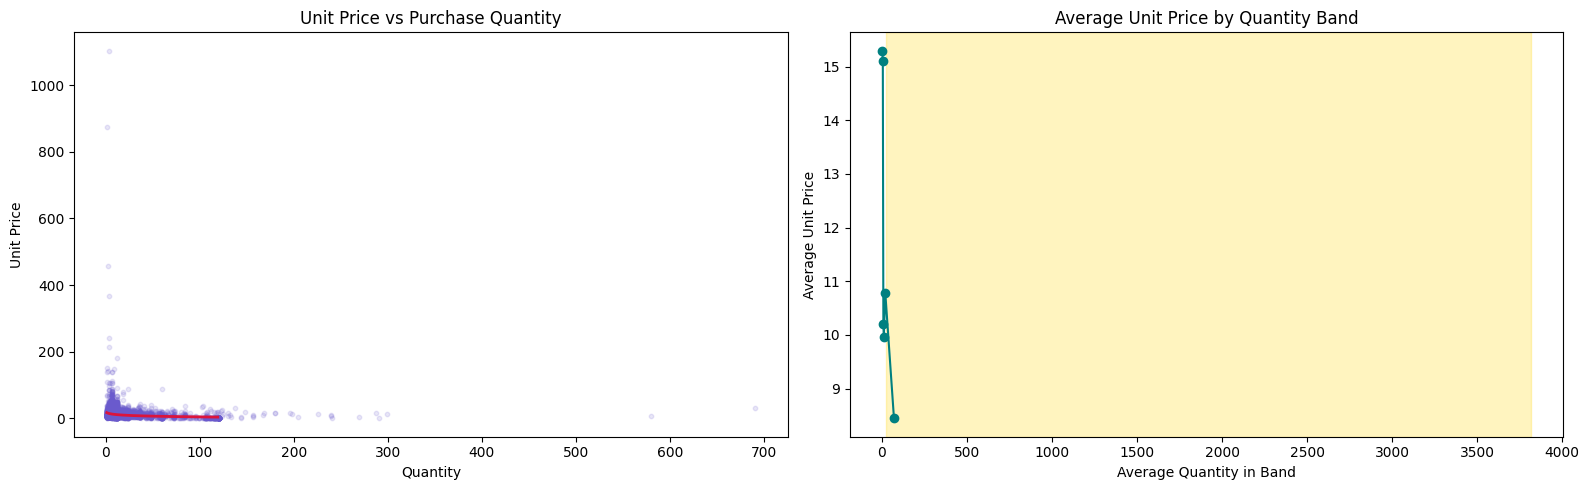

,Metric,Value
0,Rows analyzed,"2,372,321"
1,Correlation (Quantity vs Unit Price),-0.083
2,Estimated unit price change per quantity doubling,-2.260
3,Optimal quantity band for cost savings,25 to 3816
4,Average unit price in optimal band,8.44
5,Band sample size,"190,517"


In [39]:
# Bulk purchasing impact on unit price + optimal quantity band
bulk_df = pd.read_sql_query(
    """
    SELECT
        Quantity,
        PurchasePrice
    FROM purchases
    WHERE Quantity > 0 AND PurchasePrice > 0
    """,
    conn
)

# Use log quantity to model diminishing bulk discount behavior
bulk_df["log_qty"] = np.log1p(bulk_df["Quantity"])
slope, intercept = np.polyfit(bulk_df["log_qty"], bulk_df["PurchasePrice"], 1)
price_drop_per_doubling = slope * np.log(2)

# Build purchase-size bands and find the most cost-efficient stable band
bulk_df["qty_band"] = pd.qcut(bulk_df["Quantity"], q=10, duplicates="drop")
band_summary = (
    bulk_df.groupby("qty_band", as_index=False)
    .agg(
        avg_qty=("Quantity", "mean"),
        min_qty=("Quantity", "min"),
        max_qty=("Quantity", "max"),
        avg_unit_price=("PurchasePrice", "mean"),
        line_count=("Quantity", "size")
    )
    .sort_values("avg_qty")
)

min_lines = max(100, int(0.01 * len(bulk_df)))
stable_bands = band_summary[band_summary["line_count"] >= min_lines].copy()
optimal_band = stable_bands.loc[stable_bands["avg_unit_price"].idxmin()]

# Visuals
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_n = min(10000, len(bulk_df))
sample = bulk_df.sample(sample_n, random_state=42)
axes[0].scatter(sample["Quantity"], sample["PurchasePrice"], alpha=0.15, s=10, color="slateblue")

x_grid = np.linspace(bulk_df["Quantity"].min(), bulk_df["Quantity"].quantile(0.99), 200)
y_grid = intercept + slope * np.log1p(x_grid)
axes[0].plot(x_grid, y_grid, color="crimson", linewidth=2)
axes[0].set_title("Unit Price vs Purchase Quantity")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Unit Price")

axes[1].plot(band_summary["avg_qty"], band_summary["avg_unit_price"], marker="o", color="teal")
axes[1].axvspan(optimal_band["min_qty"], optimal_band["max_qty"], color="gold", alpha=0.25)
axes[1].set_title("Average Unit Price by Quantity Band")
axes[1].set_xlabel("Average Quantity in Band")
axes[1].set_ylabel("Average Unit Price")

plt.tight_layout()
plt.show()

results = pd.DataFrame(
    {
        "Metric": [
            "Rows analyzed",
            "Correlation (Quantity vs Unit Price)",
            "Estimated unit price change per quantity doubling",
            "Optimal quantity band for cost savings",
            "Average unit price in optimal band",
            "Band sample size"
        ],
        "Value": [
            f"{len(bulk_df):,}",
            f"{bulk_df['Quantity'].corr(bulk_df['PurchasePrice']):.3f}",
            f"{price_drop_per_doubling:.3f}",
            f"{int(optimal_band['min_qty'])} to {int(optimal_band['max_qty'])}",
            f"{optimal_band['avg_unit_price']:.2f}",
            f"{int(optimal_band['line_count']):,}"
        ]
    }
)

results

**Which vendor have low inventory turnover, indicating excess stock and slow-moving products?**

Low-turnover threshold (Q1): 0.927
Vendors flagged (after volume filter): 24


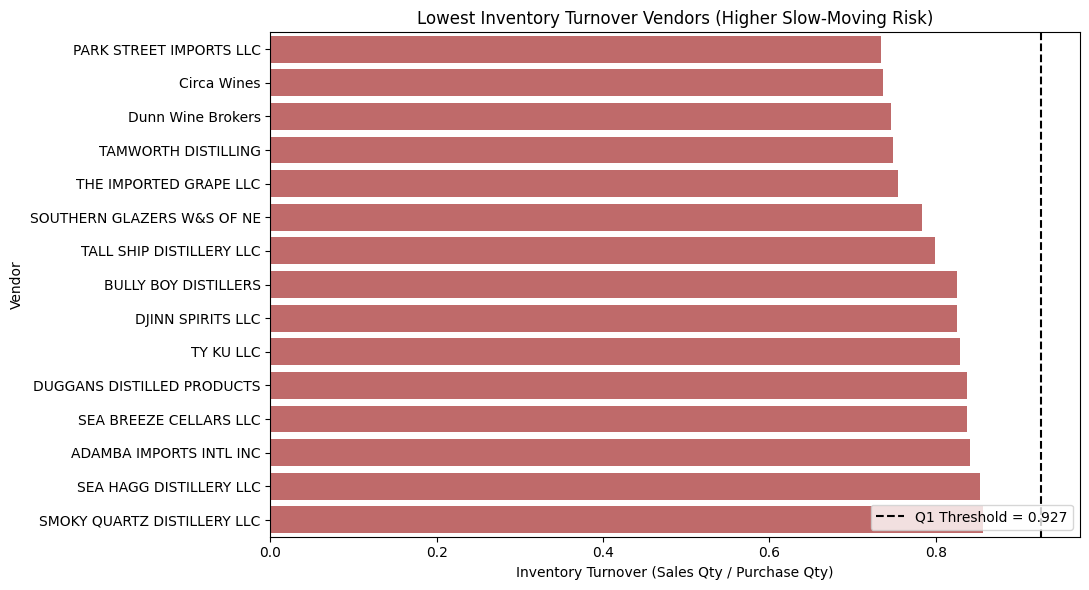

,VendorNumber,VendorName,total_purchase_qty,total_sales_qty,inventory_turnover
0,6830,PARK STREET IMPORTS LLC,"3,322","2,440",0.734
1,1650,Circa Wines,"3,320","2,443",0.736
2,17037,Dunn Wine Brokers,"5,448","4,063",0.746
3,173357,TAMWORTH DISTILLING,"1,990","1,488",0.748
4,90017,THE IMPORTED GRAPE LLC,"2,280","1,719",0.754
5,2000,SOUTHERN GLAZERS W&S OF NE,"4,198","3,288",0.783
6,28776,TALL SHIP DISTILLERY LLC,"2,236","1,786",0.799
7,1189,BULLY BOY DISTILLERS,"5,382","4,447",0.826
8,2450,DJINN SPIRITS LLC,"2,637","2,177",0.826
9,9260,TY KU LLC,"3,003","2,490",0.829


In [40]:
# Vendors with low inventory turnover (slow-moving stock risk)
low_turnover_query = """
WITH vendor_turnover AS (
    SELECT
        VendorNumber,
        VendorName,
        SUM(TotalPurchaseQuantity) AS total_purchase_qty,
        SUM(TotalSalesQuantity) AS total_sales_qty,
        CASE
            WHEN SUM(TotalPurchaseQuantity) = 0 THEN NULL
            ELSE 1.0 * SUM(TotalSalesQuantity) / SUM(TotalPurchaseQuantity)
        END AS inventory_turnover
    FROM vendor_sales_summary
    GROUP BY VendorNumber, VendorName
)
SELECT
    VendorNumber,
    VendorName,
    total_purchase_qty,
    total_sales_qty,
    ROUND(inventory_turnover, 3) AS inventory_turnover
FROM vendor_turnover
WHERE inventory_turnover IS NOT NULL
ORDER BY inventory_turnover ASC;
"""

vendor_turnover = pd.read_sql_query(low_turnover_query, conn)

# Focus on meaningful-volume vendors to avoid tiny-volume noise
min_purchase_qty = vendor_turnover["total_purchase_qty"].quantile(0.25)
volume_filtered = vendor_turnover[vendor_turnover["total_purchase_qty"] >= min_purchase_qty].copy()

risk_threshold = volume_filtered["inventory_turnover"].quantile(0.25)
low_turnover_vendors = (
    volume_filtered[volume_filtered["inventory_turnover"] <= risk_threshold]
    .sort_values(["inventory_turnover", "total_purchase_qty"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Low-turnover threshold (Q1): {risk_threshold:.3f}")
print(f"Vendors flagged (after volume filter): {len(low_turnover_vendors)}")

# Top 15 lowest-turnover vendors for action
top15_low_turnover = low_turnover_vendors.head(15).copy()
top15_low_turnover_display = top15_low_turnover.copy()
top15_low_turnover_display["total_purchase_qty"] = top15_low_turnover_display["total_purchase_qty"].map(lambda v: f"{v:,.0f}")
top15_low_turnover_display["total_sales_qty"] = top15_low_turnover_display["total_sales_qty"].map(lambda v: f"{v:,.0f}")

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top15_low_turnover,
    y="VendorName",
    x="inventory_turnover",
    color="indianred"
 )
plt.axvline(risk_threshold, ls="--", color="black", label=f"Q1 Threshold = {risk_threshold:.3f}")
plt.title("Lowest Inventory Turnover Vendors (Higher Slow-Moving Risk)")
plt.xlabel("Inventory Turnover (Sales Qty / Purchase Qty)")
plt.ylabel("Vendor")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

top15_low_turnover_display

**How much capital is locked in unsold inventory per vendor, and which vendor contribute the most to it?**

Total estimated locked capital: 13.22M
Highest contributor: MARTIGNETTI COMPANIES (1.39M, 10.53% of total)


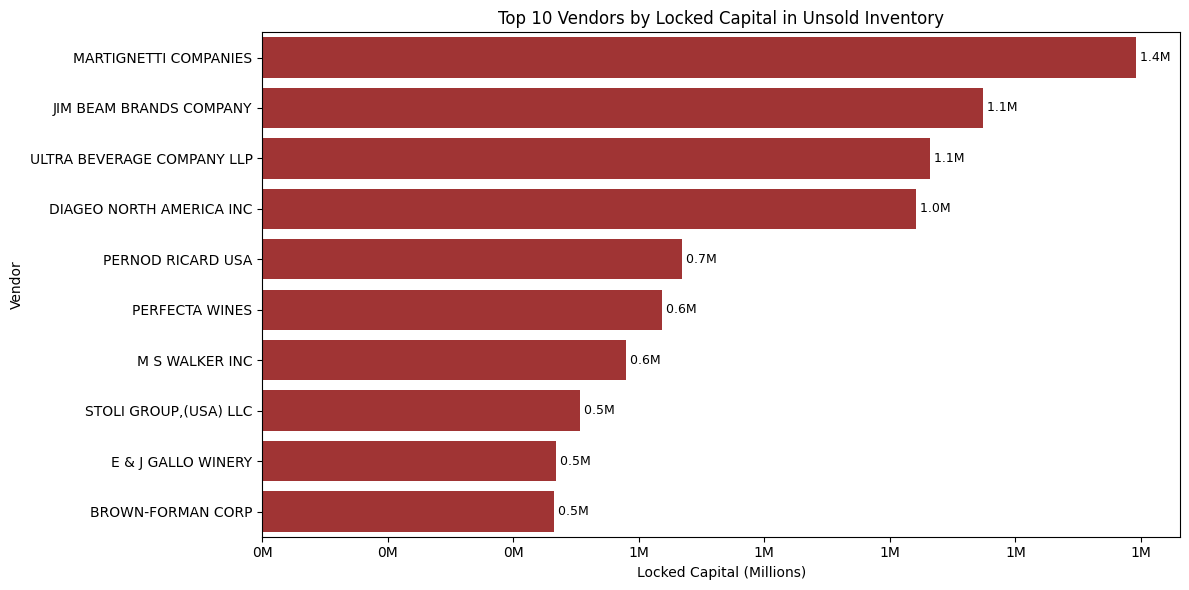

,VendorNumber,VendorName,unsold_qty,avg_unit_cost,locked_capital,share_pct,cumulative_share_pct
0,4425,MARTIGNETTI COMPANIES,"131,993",10.55,1.39M,10.53%,10.53%
1,12546,JIM BEAM BRANDS COMPANY,"129,843",8.84,1.15M,8.69%,19.22%
2,9165,ULTRA BEVERAGE COMPANY LLP,"87,159",12.20,1.06M,8.04%,27.26%
3,3960,DIAGEO NORTH AMERICA INC,"111,655",9.33,1.04M,7.88%,35.15%
4,17035,PERNOD RICARD USA,"45,659",14.64,0.67M,5.06%,40.20%
5,10754,PERFECTA WINES,"61,952",10.27,0.64M,4.81%,45.02%
6,9552,M S WALKER INC,"72,888",7.96,0.58M,4.39%,49.41%
7,8664,"STOLI GROUP,(USA) LLC","43,528",11.64,0.51M,3.83%,53.24%
8,3252,E & J GALLO WINERY,"70,690",6.61,0.47M,3.54%,56.78%
9,1128,BROWN-FORMAN CORP,"34,615",13.45,0.47M,3.52%,60.30%


In [41]:
# Locked capital in unsold inventory by vendor
locked_capital_query = """
WITH vendor_brand_stock AS (
    SELECT
        VendorNumber,
        VendorName,
        SUM(TotalPurchaseQuantity) AS purchase_qty,
        SUM(TotalSalesQuantity) AS sales_qty,
        SUM(TotalPurchaseDollars) AS purchase_dollars
    FROM vendor_sales_summary
    GROUP BY VendorNumber, VendorName, Brand
), vendor_agg AS (
    SELECT
        VendorNumber,
        VendorName,
        SUM(CASE WHEN purchase_qty > sales_qty THEN purchase_qty - sales_qty ELSE 0 END) AS unsold_qty,
        SUM(CASE WHEN purchase_qty > 0 THEN purchase_dollars ELSE 0 END) AS purchase_dollars,
        SUM(CASE WHEN purchase_qty > 0 THEN purchase_qty ELSE 0 END) AS purchase_qty
    FROM vendor_brand_stock
    GROUP BY VendorNumber, VendorName
)
SELECT
    VendorNumber,
    VendorName,
    unsold_qty,
    CASE
        WHEN purchase_qty = 0 THEN 0
        ELSE 1.0 * purchase_dollars / purchase_qty
    END AS avg_unit_cost,
    (
        unsold_qty * CASE
            WHEN purchase_qty = 0 THEN 0
            ELSE 1.0 * purchase_dollars / purchase_qty
        END
    ) AS locked_capital
FROM vendor_agg
WHERE unsold_qty > 0
ORDER BY locked_capital DESC;
"""

locked_capital_df = pd.read_sql_query(locked_capital_query, conn)
total_locked_capital = locked_capital_df["locked_capital"].sum()

locked_capital_df["share_pct"] = locked_capital_df["locked_capital"] / total_locked_capital * 100
locked_capital_df["cumulative_share_pct"] = locked_capital_df["share_pct"].cumsum()

top10_locked = locked_capital_df.head(10).copy()
top_vendor = top10_locked.iloc[0]

print(f"Total estimated locked capital: {total_locked_capital/1_000_000:.2f}M")
print(
    f"Highest contributor: {top_vendor['VendorName']} "
    f"({top_vendor['locked_capital']/1_000_000:.2f}M, {top_vendor['share_pct']:.2f}% of total)"
 )

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_locked, y="VendorName", x="locked_capital", color="firebrick")
plt.title("Top 10 Vendors by Locked Capital in Unsold Inventory")
plt.xlabel("Locked Capital (Millions)")
plt.ylabel("Vendor")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))

for p in plt.gca().patches:
    w = p.get_width()
    y = p.get_y() + p.get_height() / 2
    plt.gca().text(w, y, f" {w/1_000_000:.1f}M", va="center", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

locked_capital_display = top10_locked.copy()
locked_capital_display["unsold_qty"] = locked_capital_display["unsold_qty"].map(lambda v: f"{v:,.0f}")
locked_capital_display["avg_unit_cost"] = locked_capital_display["avg_unit_cost"].map(lambda v: f"{v:.2f}")
locked_capital_display["locked_capital"] = (
    locked_capital_display["locked_capital"] / 1_000_000
).map(lambda v: f"{v:.2f}M")
locked_capital_display["share_pct"] = locked_capital_display["share_pct"].map(lambda v: f"{v:.2f}%")
locked_capital_display["cumulative_share_pct"] = locked_capital_display["cumulative_share_pct"].map(lambda v: f"{v:.2f}%")

locked_capital_display[[
    "VendorNumber",
    "VendorName",
    "unsold_qty",
    "avg_unit_cost",
    "locked_capital",
    "share_pct",
    "cumulative_share_pct"
]]

**What is the 95% confidence intervals for profit margine of top-performing and low-performing vendors?**

In [42]:
# 95% CI for profit margin: top-performing vs low-performing vendors
perf_vendor = pd.read_sql_query(
    """
    SELECT
        VendorNumber,
        VendorName,
        SUM(TotalSalesDollars) AS total_sales
    FROM vendor_sales_summary
    GROUP BY VendorNumber, VendorName
    HAVING SUM(TotalSalesDollars) > 0
    """,
    conn
)

top_cutoff = perf_vendor["total_sales"].quantile(0.75)
low_cutoff = perf_vendor["total_sales"].quantile(0.25)

top_vendors = perf_vendor.loc[perf_vendor["total_sales"] >= top_cutoff, "VendorNumber"]
low_vendors = perf_vendor.loc[perf_vendor["total_sales"] <= low_cutoff, "VendorNumber"]

margin_df = pd.read_sql_query(
    """
    SELECT
        VendorNumber,
        ProfitMargin
    FROM vendor_sales_summary
    WHERE ProfitMargin IS NOT NULL
    """,
    conn
)

top_margin = margin_df[margin_df["VendorNumber"].isin(top_vendors)]["ProfitMargin"].dropna()
low_margin = margin_df[margin_df["VendorNumber"].isin(low_vendors)]["ProfitMargin"].dropna()

def mean_ci(series, confidence=0.95):
    n = len(series)
    mean = series.mean()
    if n < 2:
        return mean, mean, mean
    se = stats.sem(series)
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h

top_mean, top_ci_low, top_ci_high = mean_ci(top_margin, 0.95)
low_mean, low_ci_low, low_ci_high = mean_ci(low_margin, 0.95)

ci_summary = pd.DataFrame(
    {
        "Group": ["Top-performing vendors", "Low-performing vendors"],
        "Vendors in group": [len(top_vendors), len(low_vendors)],
        "Observations": [len(top_margin), len(low_margin)],
        "Mean Profit Margin": [top_mean, low_mean],
        "95% CI Lower": [top_ci_low, low_ci_low],
        "95% CI Upper": [top_ci_high, low_ci_high]
    }
)

for col in ["Mean Profit Margin", "95% CI Lower", "95% CI Upper"]:
    ci_summary[col] = ci_summary[col].map(lambda v: f"{v:.2f}%")

ci_summary

,Group,Vendors in group,Observations,Mean Profit Margin,95% CI Lower,95% CI Upper
0,Top-performing vendors,32,8792,-15.29%,-25.12%,-5.45%
1,Low-performing vendors,32,229,-23.95%,-54.22%,6.31%
